In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [13]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [14]:
df = pd.read_csv('/content/train.csv', encoding='latin-1')

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [16]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Month_name'] = df['Order Date'].dt.strftime('%b')
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Month_year'] = df['Order Date'].dt.to_period('M')

print("Data Loaded ! Shape : ",df.shape)

Data Loaded ! Shape :  (9800, 24)


##Sales Trends

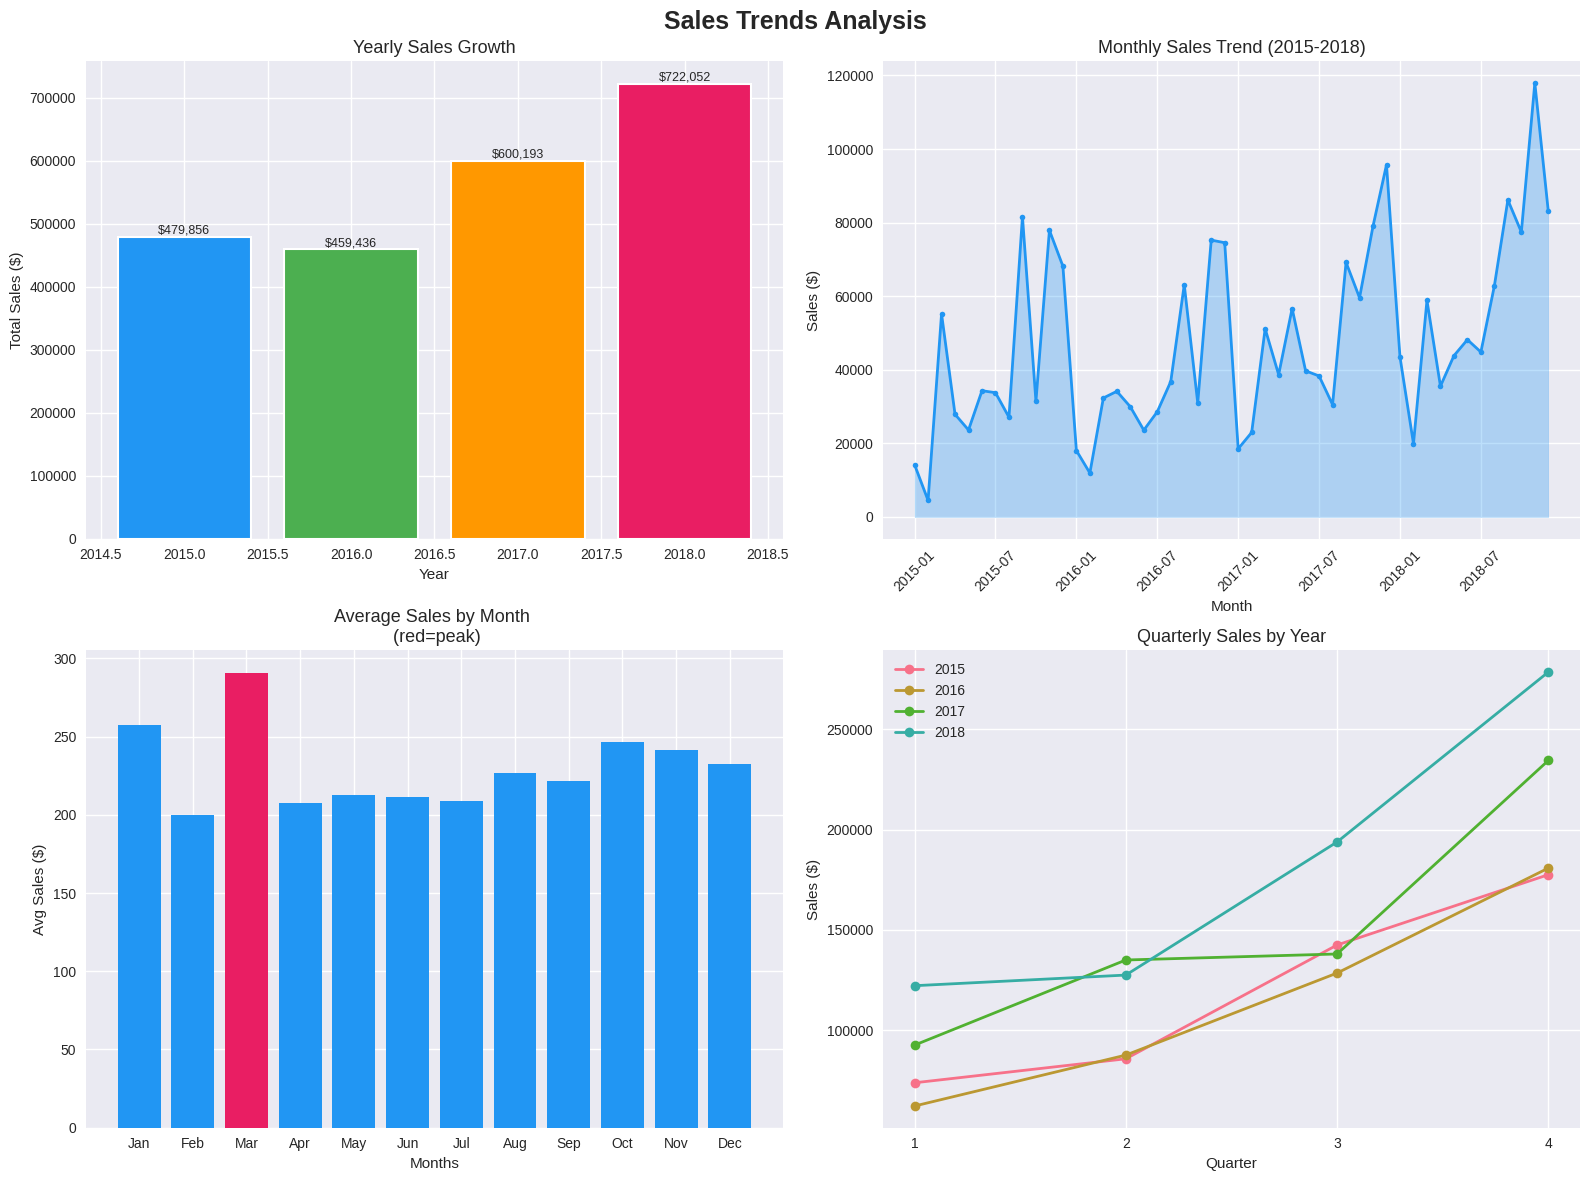

✅ Sales Trends — Done!


In [17]:
import os

fig,axes = plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Sales Trends Analysis', fontsize=18, fontweight='bold')

yearly = df.groupby('Year')['Sales'].sum()
axes[0,0].bar(
    yearly.index,
    yearly.values,
    color=['#2196F3','#4CAF50','#FF9800','#E91E63'],
    edgecolor='white',
    linewidth=1.5
)
for i, (year, val) in enumerate(yearly.items()):
  axes[0,0].text(
      year, val + 5000,
      f'${val:,.0f}',
      ha='center', fontsize=9
  )
axes[0,0].set_title('Yearly Sales Growth', fontsize=13)
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Total Sales ($)')


monthly = df.groupby('Month_year')['Sales'].sum().reset_index()
monthly['Month_year'] = monthly['Month_year'].astype(str)

axes[0,1].plot(
    range(len(monthly)),
    monthly['Sales'].values,
    color='#2196F3',
    linewidth=2,
    marker='o',
    markersize=4
)
axes[0,1].fill_between(
    range(len(monthly)),
    monthly['Sales'].values,
    alpha=0.3,
    color='#2196F3'
)
axes[0,1].set_title('Monthly Sales Trend (2015-2018)', fontsize=13)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].set_xticks(range(0, len(monthly), 6))
axes[0,1].set_xticklabels(monthly['Month_year'].iloc[::6],rotation=45)

monthly_avg = df.groupby('Month')['Sales'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

colors = [
    '#E91E63' if v == monthly_avg.max()
    else '#2196F3'
    for v in monthly_avg.values
]
axes[1,0].bar(
    month_names,
    monthly_avg.values,
    color=colors
)
axes[1,0].set_title('Average Sales by Month \n (red=peak)', fontsize=13)
axes[1,0].set_xlabel('Months')
axes[1,0].set_ylabel('Avg Sales ($)')


quarterly = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
for year in quarterly['Year'].unique():
  data = quarterly[quarterly['Year'] == year]
  axes[1,1].plot(
      data['Quarter'],
      data['Sales'],
      marker='o',
      label=str(year),
      linewidth=2
  )

axes[1,1].set_title('Quarterly Sales by Year', fontsize=13)
axes[1,1].set_xlabel('Quarter')
axes[1,1].set_ylabel('Sales ($)')
axes[1,1].legend()
axes[1,1].set_xticks([1,2,3,4])

plt.tight_layout()

os.makedirs('notebooks', exist_ok=True)
plt.savefig(
    'notebooks/02_sales_trends.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Sales Trends — Done!")

##Categorical Analysis

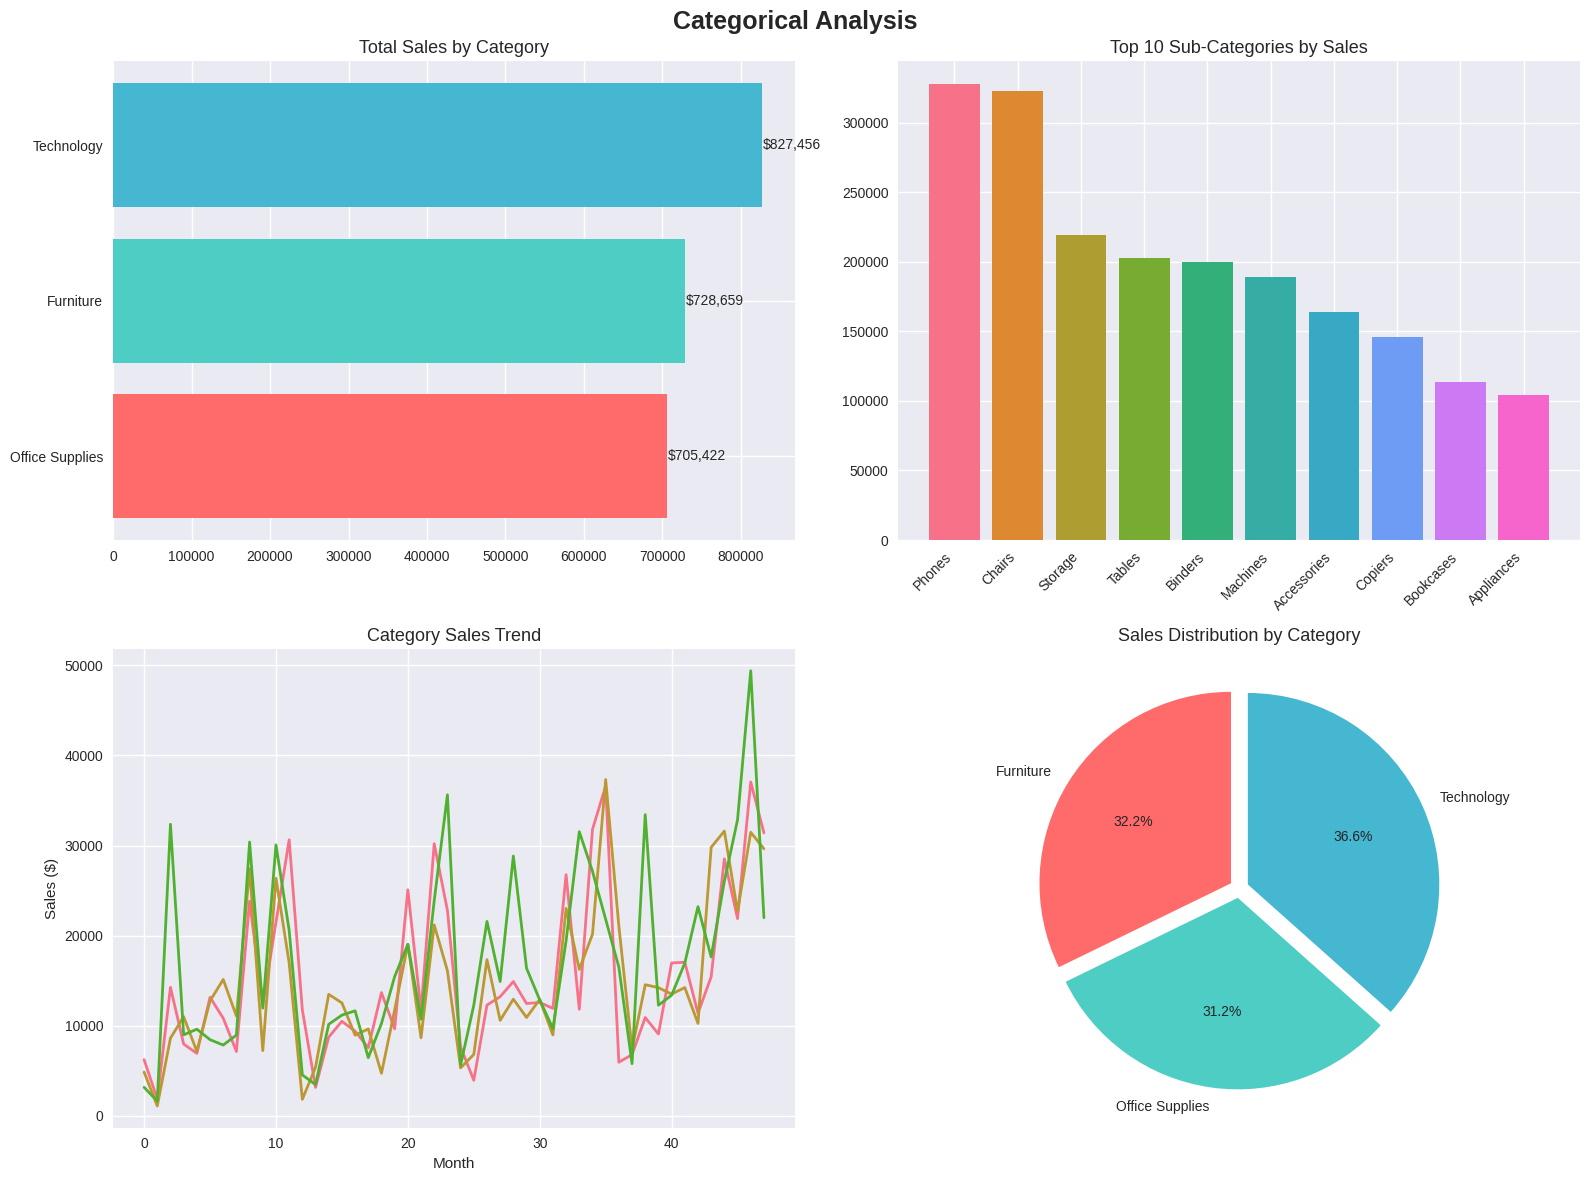

✅ Category Analysis — Done!


In [18]:
fig,axes = plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Categorical Analysis', fontsize=18, fontweight='bold')

cat_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=True)
axes[0,0].barh(
    cat_sales['Category'],
    cat_sales['Sales'],
    color=['#FF6B6B','#4ECDC4','#45B7D1']
)
for i, sales_val in enumerate(cat_sales['Sales']):
  axes[0,0].text(
      sales_val + 1000, i,
      f'${sales_val:,.0f}',
      va='center', fontsize=10
  )
axes[0,0].set_title('Total Sales by Category', fontsize=13)

sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
axes[0,1].bar(
    range(len(sub_sales)),
    sub_sales.values,
    color=sns.color_palette("husl", 10)
)
axes[0,1].set_xticks(range(len(sub_sales)))
axes[0,1].set_xticklabels(sub_sales.index, rotation=45, ha='right')

axes[0,1].set_title("Top 10 Sub-Categories by Sales", fontsize=13)

for cat in df['Category'].unique():
  cat_monthly = df[df['Category']==cat].groupby('Month_year')['Sales'].sum()
  axes[1,0].plot(
      range(len(cat_monthly)),
      cat_monthly.values,
      linewidth=2,
      label=cat
  )

axes[1,0].set_title("Category Sales Trend", fontsize=13)
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Sales ($)')

cat_total = df.groupby('Category')['Sales'].sum()
axes[1,1].pie(
    cat_total.values,
    labels=cat_total.index,
    autopct='%1.1f%%',
    colors=['#FF6B6B','#4ECDC4','#45B7D1'],
    startangle=90,
    explode=(0.05, 0.05, 0.05)
)
axes[1,1].set_title("Sales Distribution by Category", fontsize=13)

plt.tight_layout()
plt.savefig(
    'notebooks/03_category_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Category Analysis — Done!")

##Regional Analysis

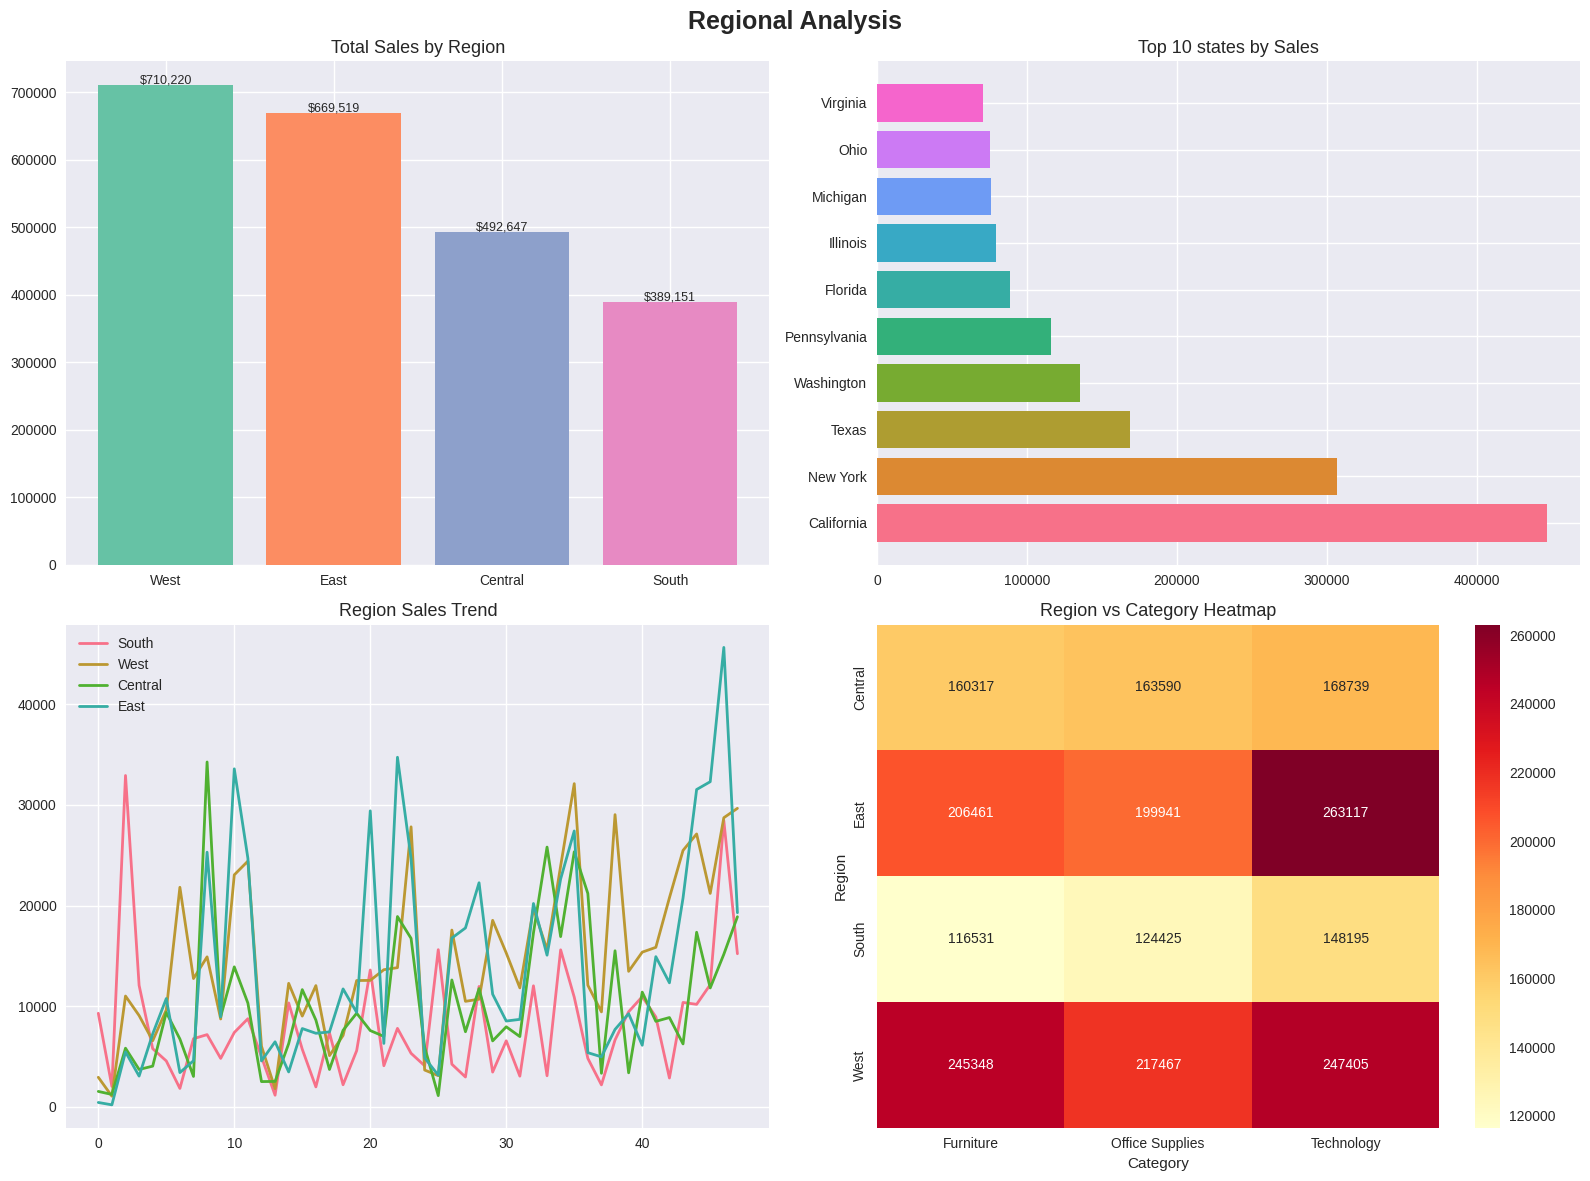

✅ Regional Analysis — Done!


In [19]:
fig, axes = plt.subplots(2,2 , figsize=(16,12))
fig.suptitle('Regional Analysis', fontsize=18, fontweight='bold')

reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
colors = sns.color_palette('Set2', 4)
axes[0,0].bar(
    reg_sales.index,
    reg_sales.values,
    color=colors
)
for i, val in enumerate(reg_sales.values):
  axes[0,0].text(
        i, val + 2000,
        f'${val:,.0f}',
        ha='center', fontsize=9
    )
axes[0,0].set_title('Total Sales by Region', fontsize=13)

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
axes[0,1].barh(
    state_sales.index,
    state_sales.values,
    color=sns.color_palette("husl", 10)
)
axes[0,1].set_title("Top 10 states by Sales", fontsize=13)

for reg in df['Region'].unique():
  reg_monthly = df[df['Region']==reg].groupby('Month_year')['Sales'].sum()
  axes[1,0].plot(
      range(len(reg_monthly)),
      reg_monthly.values,
      label=reg,
      linewidth=2
  )

axes[1,0].set_title('Region Sales Trend', fontsize=13)
axes[1,0].legend()

reg_cat = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()
sns.heatmap(
    reg_cat,
    ax=axes[1,1],
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)
axes[1,1].set_title('Region vs Category Heatmap', fontsize=13)

plt.tight_layout()
plt.savefig(
    'notebooks/04_regional_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Regional Analysis — Done!")

##Seasonal + Customer

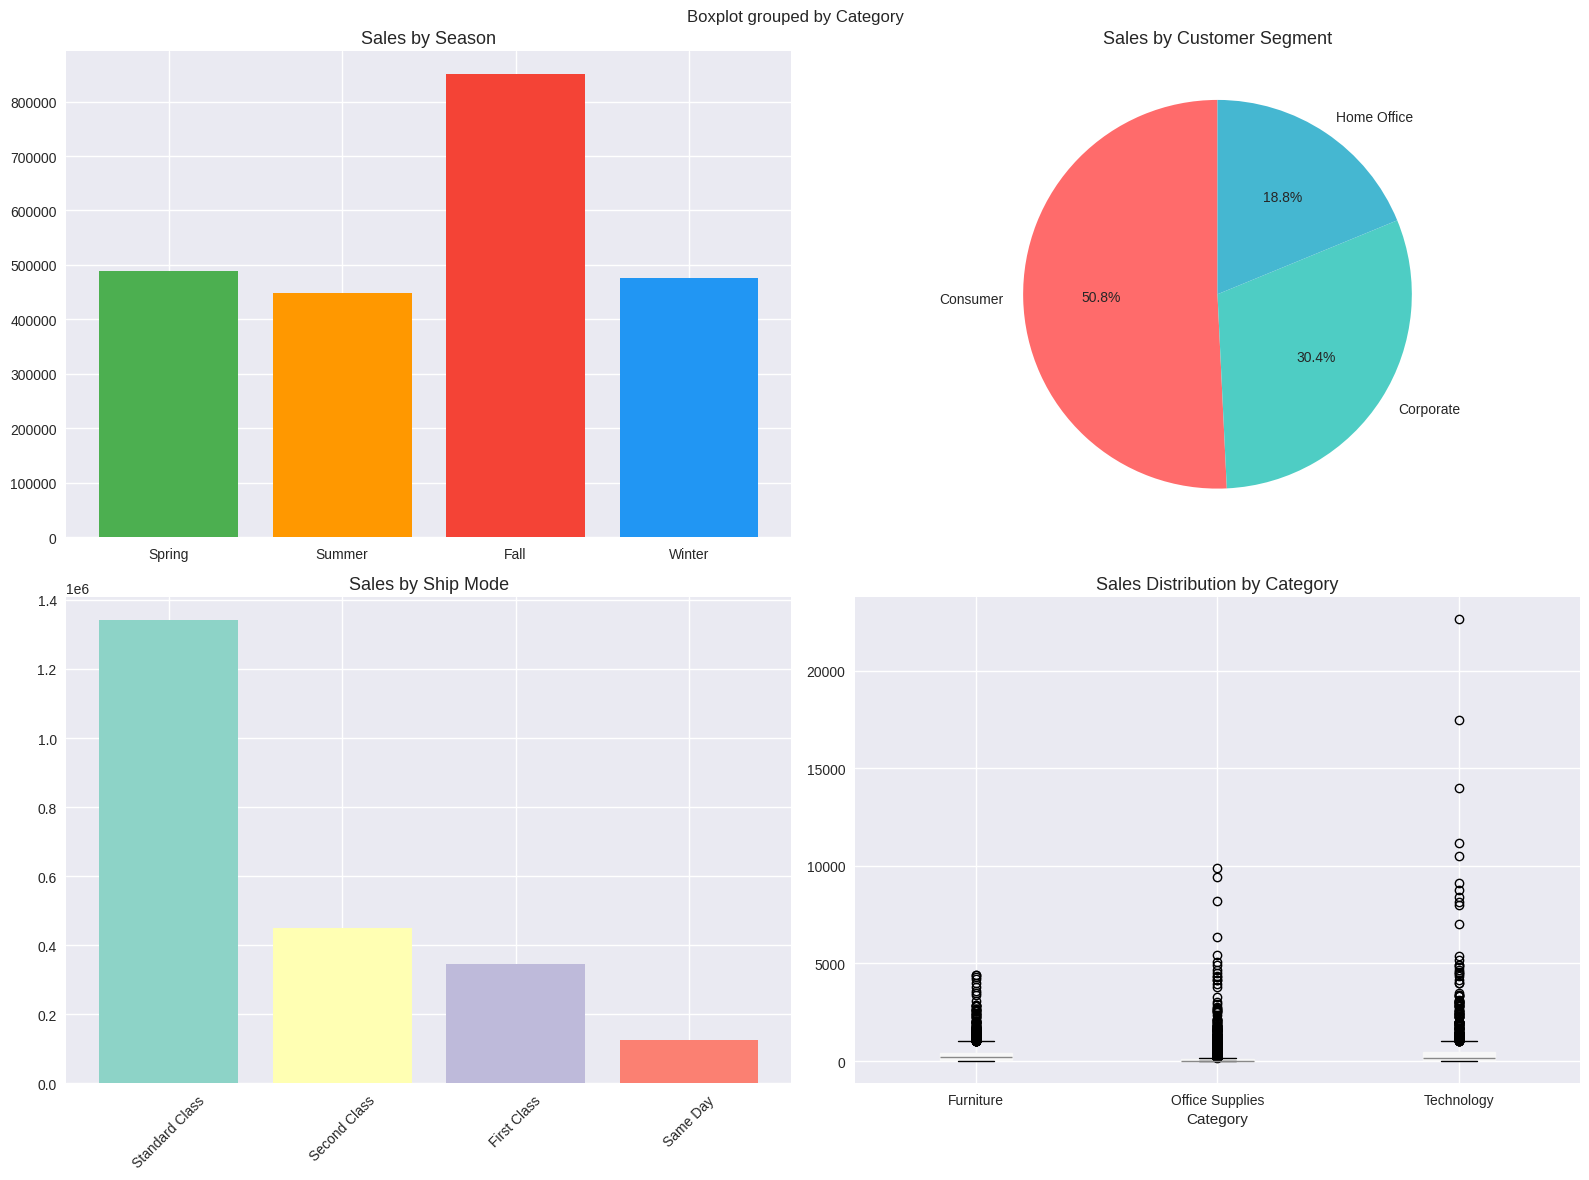

✅ Seasonal + Customer Analysis — Done!


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))
fig.suptitle('Seasonal + Customer Analysis', fontsize=18, fontweight='bold')

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
df['Season'] = df['Month'].map(season_map)
season_sales = df.groupby('Season')['Sales'].sum().reindex(['Spring', 'Summer', 'Fall', 'Winter'])
axes[0,0].bar(
    season_sales.index,
    season_sales.values,
    color=['#4CAF50','#FF9800','#F44336','#2196F3']
)
axes[0,0].set_title('Sales by Season', fontsize=13)

seg_sales = df.groupby('Segment')['Sales'].sum()
axes[0,1].pie(
    seg_sales.values,
    labels=seg_sales.index,
    autopct='%1.1f%%',
    colors=['#FF6B6B','#4ECDC4','#45B7D1'],
    startangle=90
)
axes[0,1].set_title('Sales by Customer Segment', fontsize=13)

ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)
axes[1,0].bar(
    ship_sales.index,
    ship_sales.values,
    color=sns.color_palette('Set3',4)
)
axes[1,0].set_title('Sales by Ship Mode', fontsize=13)
axes[1,0].set_xticklabels(ship_sales.index, rotation=45)

df.boxplot(
    column='Sales',
    by='Category',
    ax=axes[1,1],
    patch_artist=True
)
axes[1,1].set_title('Sales Distribution by Category', fontsize=13)
axes[1,1].set_xlabel('Category')

plt.tight_layout()
plt.savefig(
    'notebooks/05_seasonal_customer.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Seasonal + Customer Analysis — Done!")

In [22]:
print('='*50)
print('EDA KEY Insights')
print('='*50)

yearly=df.groupby('Year')['Sales'].sum()
growth = (
    (yearly.iloc[-1] - yearly.iloc[0])
    / yearly.iloc[0] * 100
)
print(f"Sales growth 2015-2018 : {growth:.1f}%")

best_month = df.groupby('Month')['Sales'].mean().idxmax()
month_names = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}
print(f"2. Best Month : {month_names[best_month]}")

best_cat = df.groupby('Category')['Sales'].sum().idxmax()
print(f"3. Best Category : {best_cat}")

best_reg = df.groupby('Region')['Sales'].sum().idxmax()
print(f"4. Best Region : {best_reg}")

best_seg = df.groupby('Segment')['Sales'].sum().idxmax()
print(f"5. Best Customer Segments : {best_seg}")

best_subcat = df.groupby('Sub-Category')['Sales'].sum().idxmax()
print(f"6. Best Sub-Category : {best_subcat}")


EDA KEY Insights
Sales growth 2015-2018 : 50.5%
2. Best Month : Mar
3. Best Category : Technology
4. Best Region : West
5. Best Customer Segments : Consumer
6. Best Sub-Category : Phones
